In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Plot styling
# directly enables consistent styling across a project without repetitive code
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")

# Load data from SQLite
conn = sqlite3.connect("../data/churn.db")
df = pd.read_sql("SELECT * FROM customers", conn)
conn.close()

print(f"✓ Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

✓ Data loaded: 7,043 rows, 21 columns


In [2]:
# Shape, column names and data types
print("── Shape ──────────────────────────")
print(df.shape)

print("\n── Data Types ─────────────────────")
print(df.dtypes)

print("\n── First 5 Rows ───────────────────")
df.head()

── Shape ──────────────────────────
(7043, 21)

── Data Types ─────────────────────
customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

── First 5 Rows ───────────────────


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# Check for missing value summary
# No missing values expected since cleaned in phase 1
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": round(df.isnull().sum() / len(df) * 100, 1)
})

missing[missing["missing_count"] > 0]

,missing_count,missing_pct


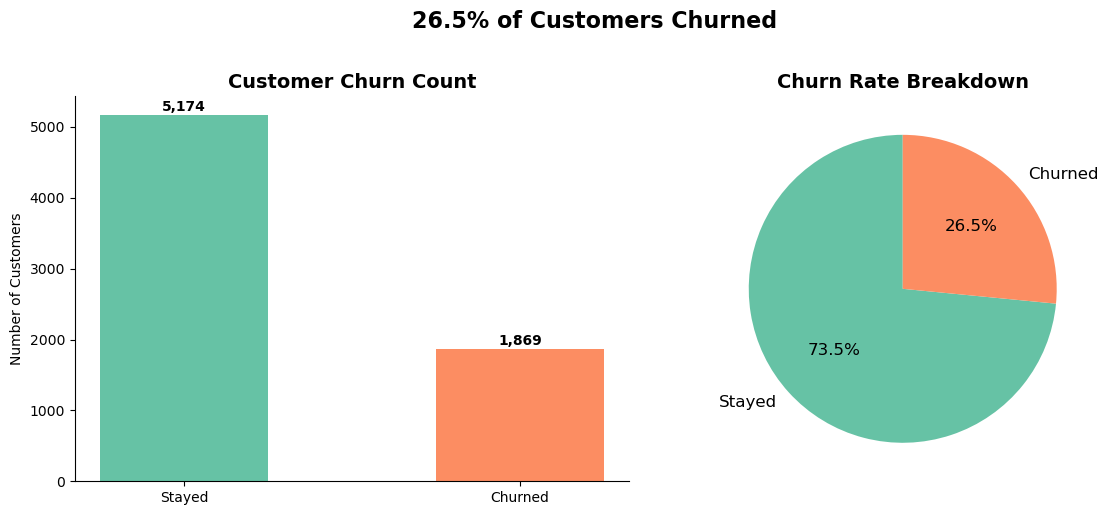

✓ Chart saved


In [5]:
# Churn distribution
# Overall churn split
churn_counts = df["churn"].value_counts()
churn_labels = ["Stayed", "Churned"]
colors = ["#66c2a5", "#fc8d62"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(churn_labels, churn_counts, color=colors, width=0.5)
axes[0].set_title("Customer Churn Count", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(churn_counts, labels=churn_labels, colors=colors,
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 12})
axes[1].set_title("Churn Rate Breakdown", fontsize=14, fontweight="bold")

plt.suptitle("26.5% of Customers Churned", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../dashboard/01_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

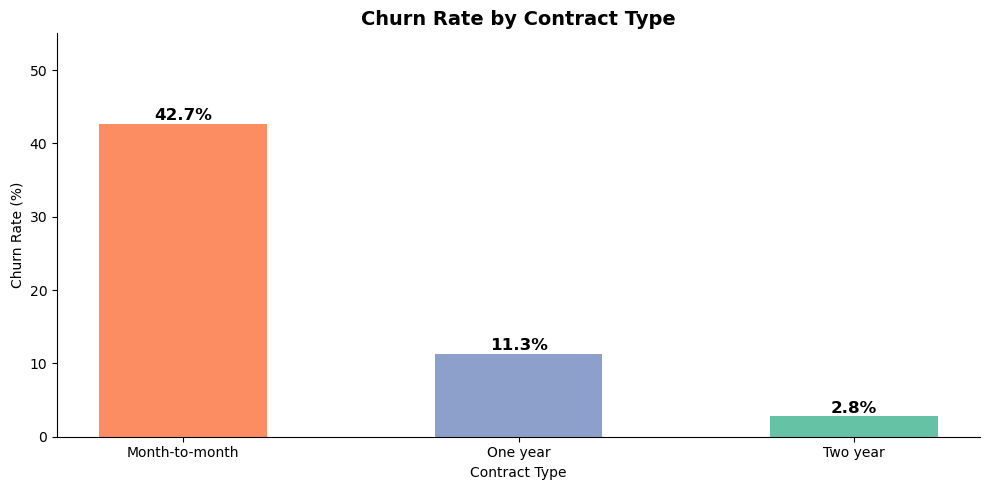

✓ Chart saved


In [6]:
# Churn by contract type
contract_churn = df.groupby("contract")["churn"].mean().reset_index()
contract_churn["churn_rate_pct"] = (contract_churn["churn"] * 100).round(1)
contract_churn = contract_churn.sort_values("churn_rate_pct", ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(contract_churn["contract"],
               contract_churn["churn_rate_pct"],
               color=["#fc8d62", "#8da0cb", "#66c2a5"],
               width=0.5)

for bar, val in zip(bars, contract_churn["churn_rate_pct"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{val}%", ha="center", fontweight="bold", fontsize=12)

plt.title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 55)
plt.tight_layout()
plt.savefig("../dashboard/02_churn_by_contract.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

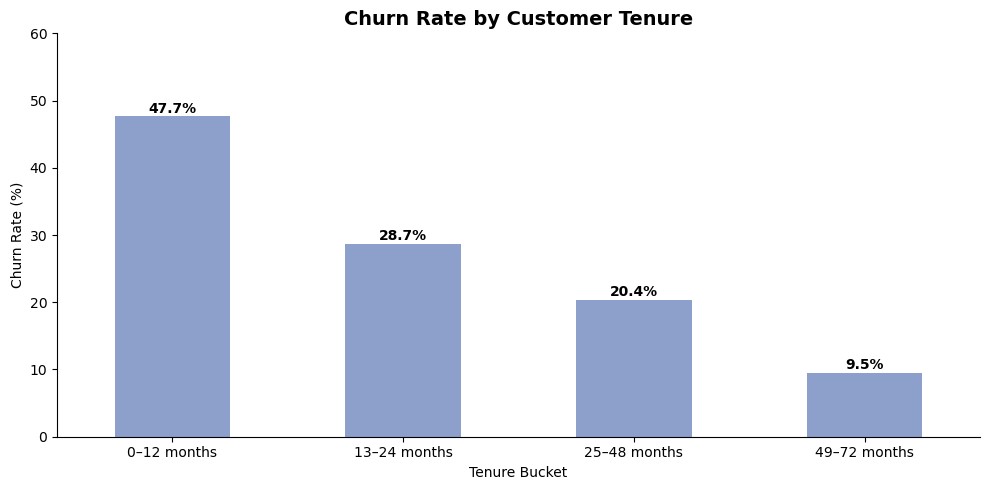

✓ Chart saved


In [7]:
# Churn by tenure
# Bin tenure into buckets
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0–12 months", "13–24 months", "25–48 months", "49–72 months"]
)

tenure_churn = df.groupby("tenure_bucket", observed=True)["churn"].mean() * 100

plt.figure(figsize=(10, 5))
tenure_churn.plot(kind="bar", color="#8da0cb", width=0.5, rot=0)
plt.title("Churn Rate by Customer Tenure", fontsize=14, fontweight="bold")
plt.xlabel("Tenure Bucket")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 60)

for i, val in enumerate(tenure_churn):
    plt.text(i, val + 0.5, f"{val:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../dashboard/03_churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

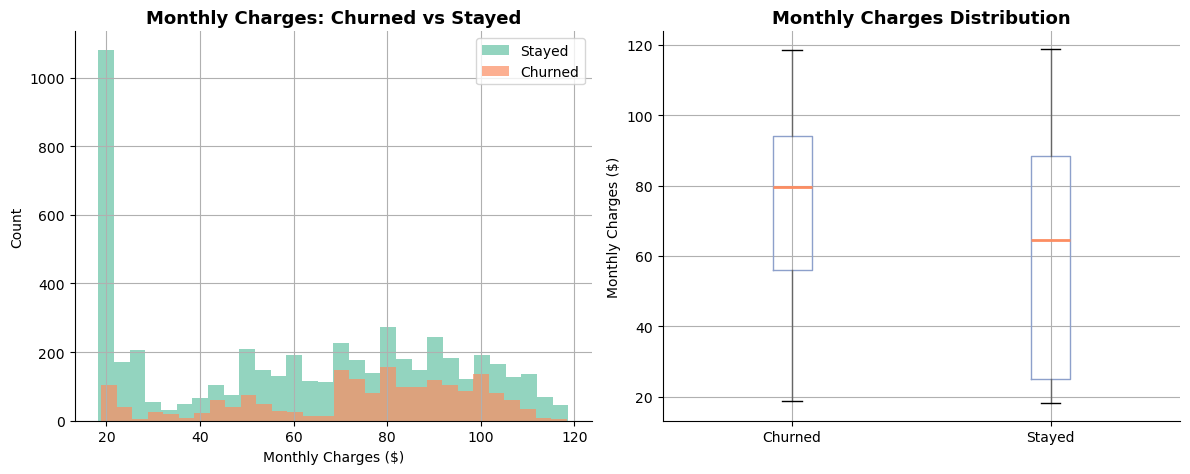

✓ Chart saved


In [8]:
# Monthly charges distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churned vs stayed monthly charges
df[df["churn"] == 0]["monthlycharges"].hist(
    ax=axes[0], bins=30, color="#66c2a5", alpha=0.7, label="Stayed")
df[df["churn"] == 1]["monthlycharges"].hist(
    ax=axes[0], bins=30, color="#fc8d62", alpha=0.7, label="Churned")
axes[0].set_title("Monthly Charges: Churned vs Stayed", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Monthly Charges ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
df["churn_label"] = df["churn"].map({0: "Stayed", 1: "Churned"})
df.boxplot(column="monthlycharges", by="churn_label", ax=axes[1],
           boxprops=dict(color="#8da0cb"),
           medianprops=dict(color="#fc8d62", linewidth=2))
axes[1].set_title("Monthly Charges Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Monthly Charges ($)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../dashboard/04_monthly_charges.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

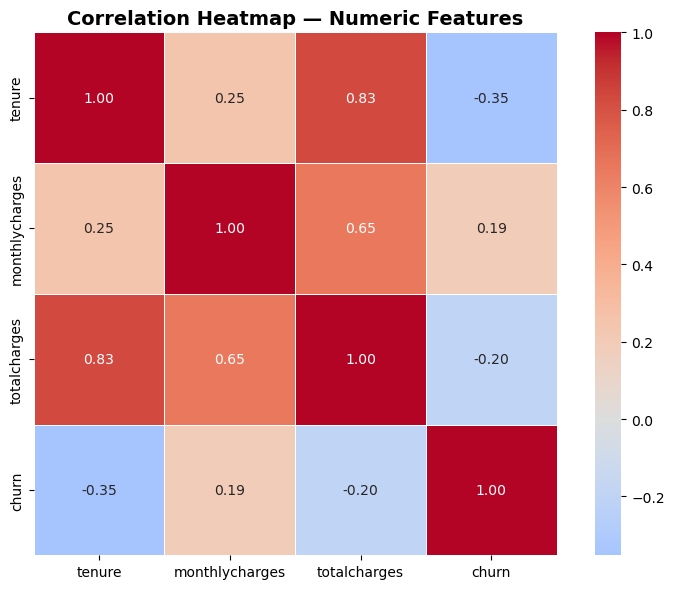

✓ Chart saved


In [9]:
# Correlation heatmap
# Select numeric columns only
numeric_cols = df[["tenure", "monthlycharges", "totalcharges", "churn"]]

plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../dashboard/05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

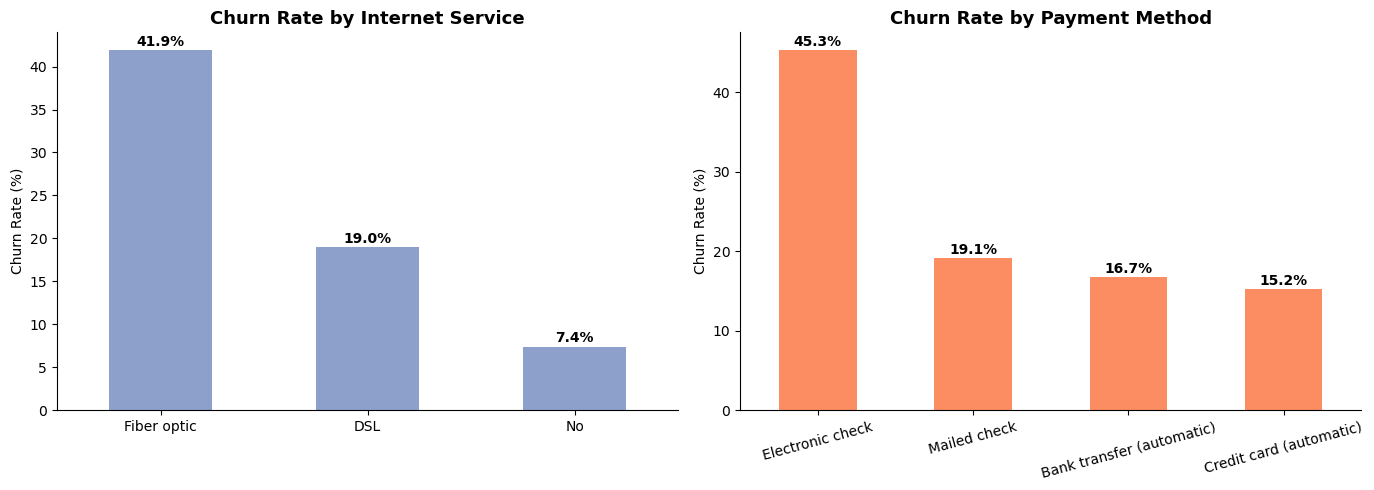

✓ Chart saved


In [10]:
# Churn by internet service & payment method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Internet service
internet_churn = df.groupby("internetservice")["churn"].mean() * 100
internet_churn.sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], color="#8da0cb", width=0.5, rot=0)
axes[0].set_title("Churn Rate by Internet Service", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xlabel("")
for i, val in enumerate(internet_churn.sort_values(ascending=False)):
    axes[0].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontweight="bold")

# Payment method
payment_churn = df.groupby("paymentmethod")["churn"].mean() * 100
payment_churn.sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="#fc8d62", width=0.5, rot=15)
axes[1].set_title("Churn Rate by Payment Method", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_xlabel("")
for i, val in enumerate(payment_churn.sort_values(ascending=False)):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../dashboard/06_churn_by_service_payment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved")

In [11]:
# EDA summary of key findings
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EDA KEY FINDINGS — TELCO CHURN ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. OVERALL CHURN RATE
   → 26.5% of customers churned

2. CONTRACT TYPE (strongest driver)
   → Month-to-month: ~43% churn
   → One year:       ~11% churn
   → Two year:        ~3% churn

3. TENURE
   → Customers in first 12 months churn the most
   → Churn drops significantly after 2 years

4. MONTHLY CHARGES
   → Churned customers pay higher monthly charges
   → Suggests price sensitivity is a factor

5. INTERNET SERVICE
   → Fiber optic customers churn more despite
     paying the highest monthly charges

6. PAYMENT METHOD
   → Electronic check users churn the most
   → Auto-pay customers (bank/credit card) churn least

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EDA KEY FINDINGS — TELCO CHURN ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. OVERALL CHURN RATE
   → 26.5% of customers churned

2. CONTRACT TYPE (strongest driver)
   → Month-to-month: ~43% churn
   → One year:       ~11% churn
   → Two year:        ~3% churn

3. TENURE
   → Customers in first 12 months churn the most
   → Churn drops significantly after 2 years

4. MONTHLY CHARGES
   → Churned customers pay higher monthly charges
   → Suggests price sensitivity is a factor

5. INTERNET SERVICE
   → Fiber optic customers churn more despite
     paying the highest monthly charges

6. PAYMENT METHOD
   → Electronic check users churn the most
   → Auto-pay customers (bank/credit card) churn least

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

